# MMT

## Emily Zuetell

## August 10, 2026

In [19]:
import os
from dotenv import load_dotenv
import xarray as xr

import geopandas as gpd

import analysis_utils
import isku_utils

import importlib

importlib.reload(analysis_utils)
importlib.reload(isku_utils)

<module 'isku_utils' from '/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py'>

In [20]:
load_dotenv()
DATA_DIR = os.environ["DATA_DIR"]
IMPACT_REGION_POLYGONS = os.environ["POREALLAS_REGIONS_POLYGONS_URI"]
SOCIOECONOMICS_URI = os.environ["POREALLAS_SOCIOECONOMICS_URI"]

In [21]:
# Impact Regions
_polygons = (
    gpd.read_parquet(IMPACT_REGION_POLYGONS)
    .rename(columns={"hierid": "region"})
    .set_index("region")
    .set_crs(epsg=4326)  # Assuming the data is WGS-82.
)

# Socioeconomics
socioeconomics = xr.open_zarr(SOCIOECONOMICS_URI)

In [22]:
betas = xr.open_zarr("2608_beta_qdm.zarr")

FileNotFoundError: /home/emily_zuetell/projects/poreallas/analysis/2608_beta_qdm.zarr does not exist

In [36]:
betas

<xarray.Dataset> Size: 150MB
Dimensions:        (age_cohort: 3, region: 24378, tas_bin: 170, degree: 4,
                    covarname: 3)
Coordinates:
  * age_cohort     (age_cohort) object 24B 'age0to4' 'age5to64' 'age65plus'
  * region         (region) object 195kB 'ABW' ... 'ZWE.9.R19a261b63a503c9c'
  * tas_bin        (tas_bin) float64 1kB -104.5 -103.5 -102.5 ... 62.5 63.5 64.5
  * degree         (degree) int64 32B 1 2 3 4
  * covarname      (covarname) object 24B '1' 'climtas' 'loggdppc'
Data variables:
    beta           (age_cohort, region, tas_bin) float32 50MB dask.array<chunksize=(1, 6095, 43), meta=np.ndarray>
    beta_coldonly  (age_cohort, region, tas_bin) float32 50MB dask.array<chunksize=(1, 6095, 43), meta=np.ndarray>
    beta_hotonly   (age_cohort, region, tas_bin) float32 50MB dask.array<chunksize=(1, 6095, 43), meta=np.ndarray>
    climtas        (region) float32 98kB dask.array<chunksize=(24378,), meta=np.ndarray>
    gamma          (age_cohort, degree, covarname) float32 144B dask.array<chunksize=(3, 4, 3), meta=np.ndarray>
    loggdppc       (region) float32 98kB dask.array<chunksize=(24378,), meta=np.ndarray>
    mmt            (age_cohort, region) float32 293kB dask.array<chunksize=(2, 24378), meta=np.ndarray>

# MMT

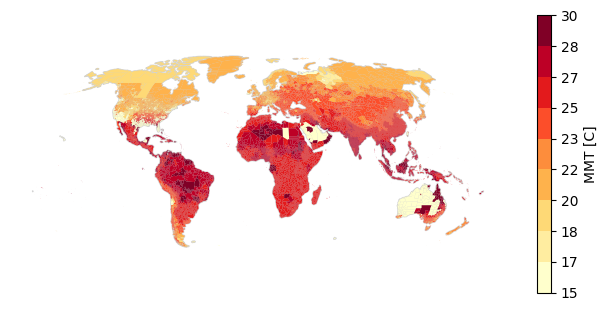

In [ ]:
_polygons_mmt = analysis_utils.xarray_to_gpd(
    betas["mmt"].sel(age_cohort="age65plus"), _polygons
)

ax = analysis_utils.plot_single(
    _polygons_mmt,
    col="mmt",
    cm="YlOrRd",
    vmin=15,
    vmax=30,
    n_colors=9,
    sup_title="",
    cbar_label="MMT [C]",
)
fig = ax.figure
fig.savefig("2608_mmt.png", dpi=600, bbox_inches="tight")

# CLIMTAS

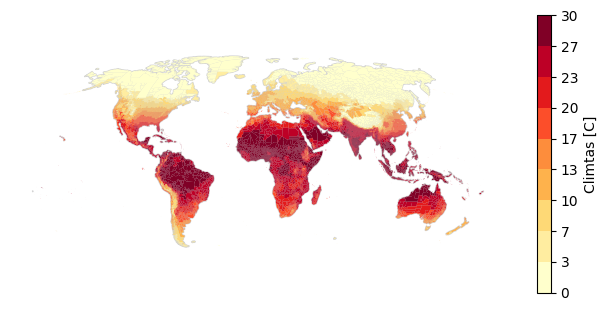

In [ ]:
_polygons_climtas = analysis_utils.xarray_to_gpd(betas["climtas"], _polygons)

ax = analysis_utils.plot_single(
    _polygons_climtas,
    col="climtas",
    cm="YlOrRd",
    vmin=0,
    vmax=30,
    n_colors=9,
    sup_title="",
    cbar_label="Climtas [C]",
)
fig = ax.figure
fig.savefig("2608_climtas.png", dpi=600, bbox_inches="tight")

# GDP

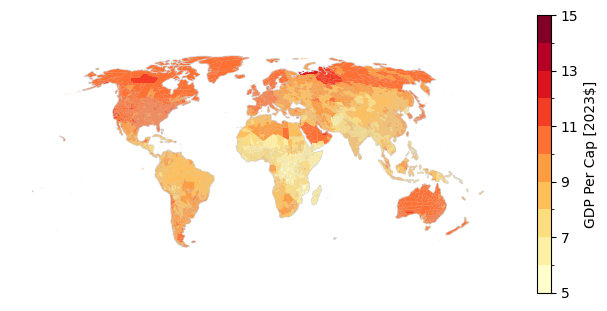

In [ ]:
_polygons_gdppc = analysis_utils.xarray_to_gpd(betas["loggdppc"], _polygons)

ax = analysis_utils.plot_single(
    _polygons_gdppc,
    col="loggdppc",
    cm="YlOrRd",
    vmin=5,
    vmax=15,
    n_colors=10,
    sup_title="",
    cbar_label="GDP Per Cap [2023$]",
)
fig = ax.figure
fig.savefig("2608_loggdppc.png", dpi=600, bbox_inches="tight")

# Scatter Plots

In [ ]:
import seaborn as sns

In [ ]:
polygons_scatter = _polygons_mmt
polygons_scatter["mmt"] = polygons_scatter["mmt"].mask(polygons_scatter["mmt"] < 0)
polygons_scatter["climtas"] = _polygons_climtas["climtas"]
polygons_scatter["gdppc"] = _polygons_gdppc["gdppc"].mask(
    _polygons_gdppc["loggdppc"] < 0
)

In [34]:
polygons_scatter[polygons_scatter["mmt"].isna()]

,region,gadmid,color,ISO,AREA,PERIMETER,geometry,age_cohort,mmt,climtas,gdppc
2328,JPN.37.1512,97158,2329,JPN,0.000014,0.015318,"POLYGON ((11632876.043 3982939.746, 11633145.0...",age65plus,NaN,12.998766,NaN
2633,TWN.2.2,186573,2634,TWN,0.000092,0.042344,"POLYGON ((10817644.792 2214932.3, 10819190.152...",age65plus,NaN,20.625719,NaN
3187,IND.12.132.459,86037,3188,IND,0.000011,0.017725,"POLYGON ((6487094.119 2429967.684, 6487250.881...",age65plus,NaN,27.237328,NaN
3192,IND.12.132.460,86042,3193,IND,0.000015,0.016257,"POLYGON ((6487693.667 2426937.322, 6487788.831...",age65plus,NaN,27.237328,NaN
4372,IND.12.132.461,87222,4373,IND,0.000002,0.007094,"POLYGON ((6486755.082 2426164.992, 6486764.456...",age65plus,NaN,27.237328,NaN
4373,IND.12.132.462,87223,4374,IND,0.000007,0.012003,"POLYGON ((6487396.293 2426164.992, 6487515.868...",age65plus,NaN,27.237328,NaN
7062,HMD,85210,7063,HMD,0.045548,1.056878,"POLYGON ((5879116.904 -5632635.752, 5881785.31...",age65plus,NaN,3.567655,NaN
14247,ATF.R3ad2a7b0834665e6,83385,14248,ATF,0.940617,11.429903,"MULTIPOLYGON (((4383085.874 -4950066.056, 4391...",age65plus,NaN,3.951815,NaN
14451,ZAF.9.313,173948,14452,ZAF,0.037806,1.053228,"MULTIPOLYGON (((3178702.231 -4973285.277, 3184...",age65plus,NaN,4.046251,NaN
14505,SGS,174206,14506,SGS,0.555565,7.022936,"MULTIPOLYGON (((-2021605.913 -6177506.948, -20...",age65plus,NaN,0.575516,NaN


In [31]:
polygons_scatter.sort_values("mmt", ascending=True)

,region,gadmid,color,ISO,AREA,PERIMETER,geometry,age_cohort,mmt,climtas,gdppc
2469,JPN.41.Rdefca2f3adf078ec,98211,2470,JPN,0.012541,0.667789,"POLYGON ((12394420.159 3811513.382, 12389291.9...",age65plus,10.5,16.258831,10.966300
2509,JPN.33.R2e75622560e2b603,98477,2510,JPN,0.024521,0.656984,"POLYGON ((12098677.086 3711545.729, 12092830.5...",age65plus,10.5,16.838453,10.429048
18392,AUS.6.738,4072,18393,AUS,0.007483,0.343908,"POLYGON ((13992246.986 -2963416.123, 13995154....",age65plus,10.5,20.771231,10.541930
18393,AUS.6.628,4073,18394,AUS,0.010280,0.497633,"POLYGON ((14002158.788 -2976565.659, 14002033....",age65plus,10.5,20.771231,10.524903
18395,AUS.6.865,4075,18396,AUS,0.001712,0.202995,"POLYGON ((13988138.361 -2966865.77, 13982797.3...",age65plus,10.5,20.771231,10.557424
...,...,...,...,...,...,...,...,...,...,...,...
20628,COL.26.852,36945,20629,COL,0.000016,0.018331,"POLYGON ((-7346035.707 1695902.557, -7346311.3...",age65plus,NaN,21.293461,NaN
21101,SP-,182783,21102,SP-,0.000018,0.019334,"POLYGON ((10737558.717 1182531.692, 10737828.6...",age65plus,NaN,21.695816,NaN
22153,IDN.14.203,88351,22154,IDN,0.000006,0.010052,"POLYGON ((11088749.861 -375602.068, 11088552.5...",age65plus,NaN,27.323967,NaN
23145,IOT,17120,23146,IOT,0.003310,0.971860,"POLYGON ((6825543.458 -773574.413, 6826798.008...",age65plus,NaN,20.809380,NaN


In [25]:
_polygons_gdppc["loggdppc"].min()

np.float32(-inf)

<Axes: xlabel='mmt', ylabel='gdppc'>

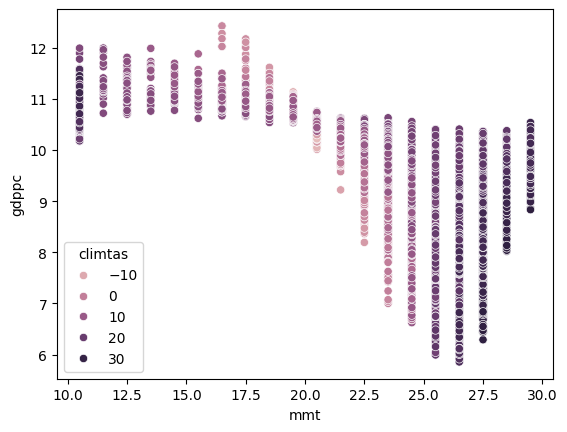

In [ ]:
sns.scatterplot(data=polygons_scatter, x="mmt", y="gdppc", hue="climtas")

<Axes: xlabel='mmt', ylabel='climtas'>

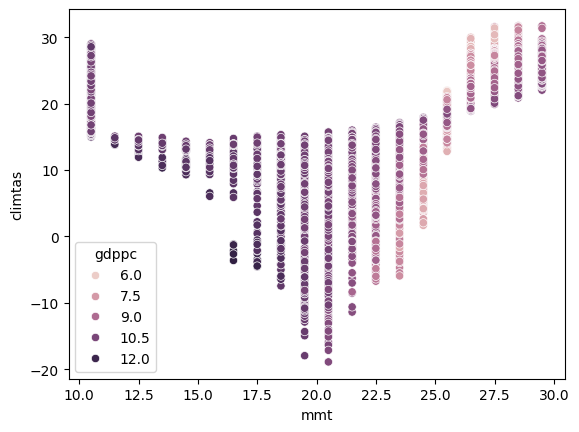

In [ ]:
sns.scatterplot(data=polygons_scatter, x="mmt", y="climtas", hue="gdppc")

# Gammas

In [ ]:
gammas = xr.open_zarr(
    "/home/emily_zuetell/projects/poreallas/scripts/data/gammas_local.zarr"
)

In [ ]:
gammas["gamma_mean"].sel(age_cohort="age65plus", degree=1, covarname="climtas").values

array(0.04369676)